# Sub-Hypothesis Exploration

This notebook investigates additional research questions:
1. **Class size vs Student Enjoyment** (enrollment vs recommendation rate)
2. **Quarter-Based Analysis** (do students perform better in certain quarters?)
3. **Study Hours vs GPA** by quarter and department


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from pathlib import Path

from src.capes_analysis import clean_capes_analysis_frame, load_capes_data
from src import sub_hypothesis_helpers as sh

root_dir = Path().resolve().parents[0]
df_raw = load_capes_data(root_dir / 'data' / 'capes_data.csv')
df_clean = clean_capes_analysis_frame(df_raw)

print(f'Clean rows: {len(df_clean):,}')
print(f'Seasons: {df_clean["Season_Name"].value_counts().to_dict()}')


Clean rows: 45,735
Seasons: {'Winter': 14121, 'Spring': 13791, 'Fall': 13267}


## 2. Class Size vs Student Enjoyment

### 2.1 Enrollment vs Recommendation Rate (Scatter)

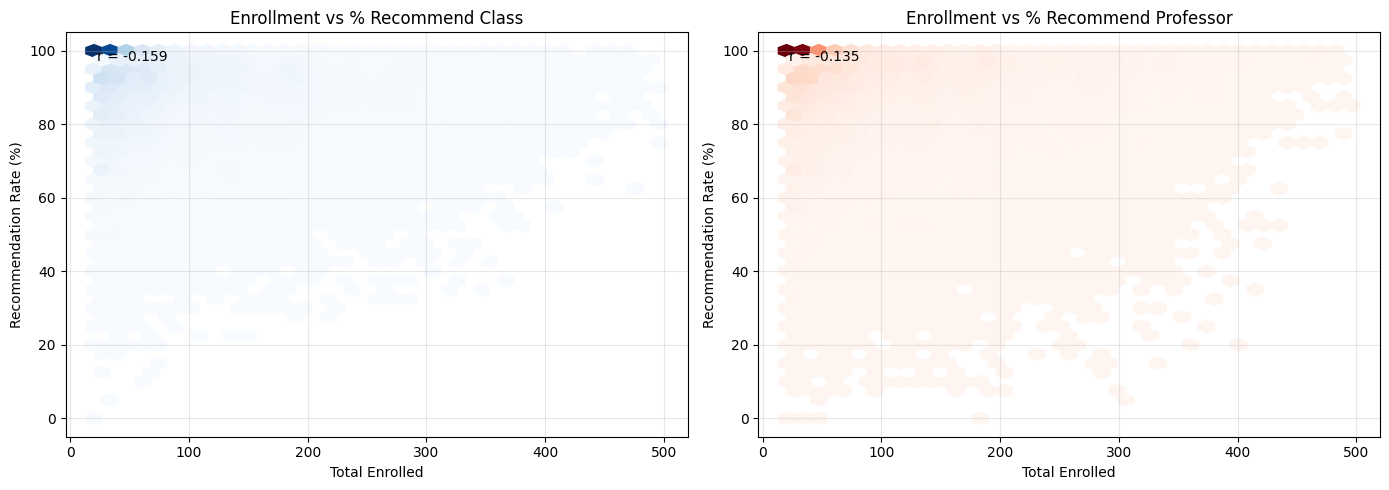

In [2]:
df_size = sh.prepare_class_size_frame(df_clean)
sh.plot_class_size_hexbin(df_size, 'figures/classsize_vs_rec.png')


### 2.2 Enrollment Bins vs Avg Recommendation Rate

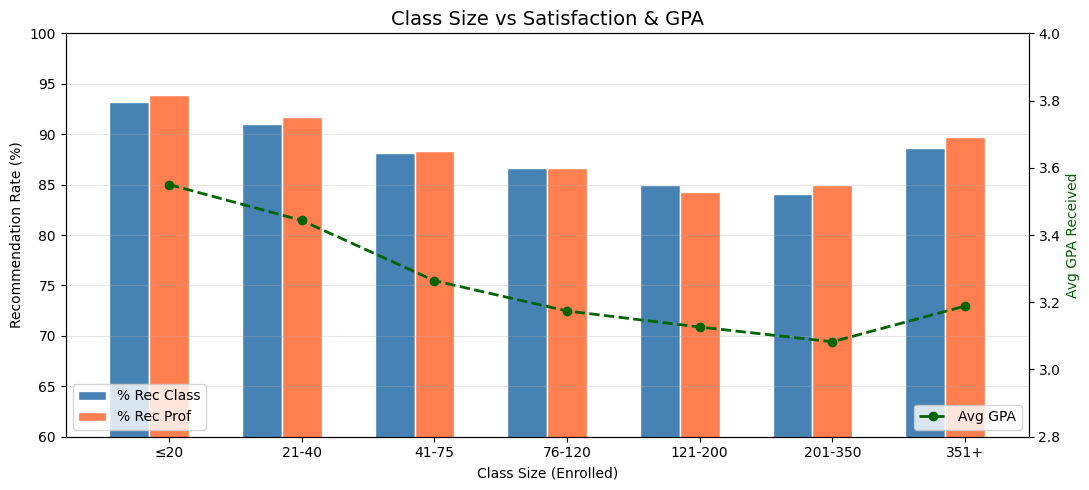

          Pct_Rec_Class  Pct_Rec_Prof  GPA_Received
Size_Bin                                           
≤20               93.17         93.87          3.55
21-40             91.02         91.66          3.44
41-75             88.18         88.29          3.26
76-120            86.64         86.63          3.17
121-200           84.96         84.22          3.13
201-350           84.02         84.93          3.08
351+              88.63         89.76          3.19


In [3]:
df_size = sh.add_size_bins(df_size)
bin_stats = sh.summarize_size_bins(df_size)
sh.plot_size_bin_summary(bin_stats, 'figures/classsize_bins.png')
bin_stats.round(3)


## 3. Quarter-Based Analysis

**Question**: Do students perform better in certain quarters (Fall / Winter / Spring / Summer)?

### 3.1 GPA by Season (Overall)

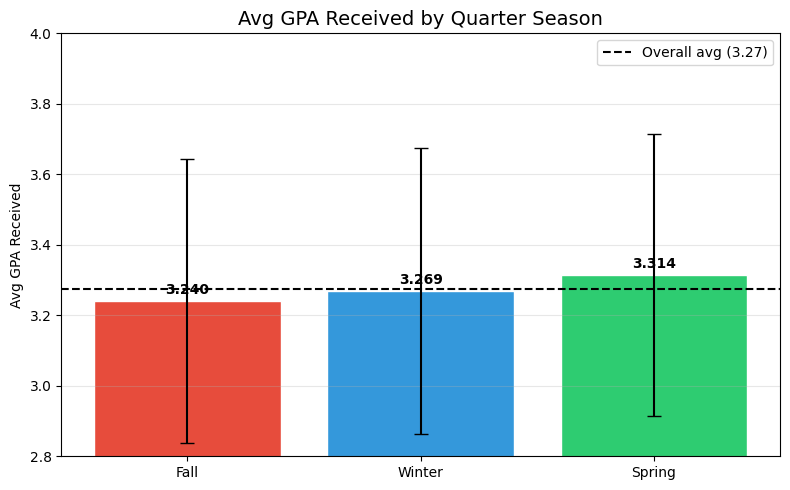

              mean    std    count
Season_Name                       
Fall         3.240  0.403  13267.0
Winter       3.269  0.405  14121.0
Spring       3.314  0.400  13791.0
Summer         NaN    NaN      NaN


In [4]:
df_season, season_order = sh.prepare_season_frame(df_clean)
season_gpa = sh.summarize_season_gpa(df_season, season_order)
sh.plot_season_gpa(season_gpa, 'figures/quarter_gpa.png')
season_gpa.round(3)


### 3.2 GPA by Season — Focus Departments

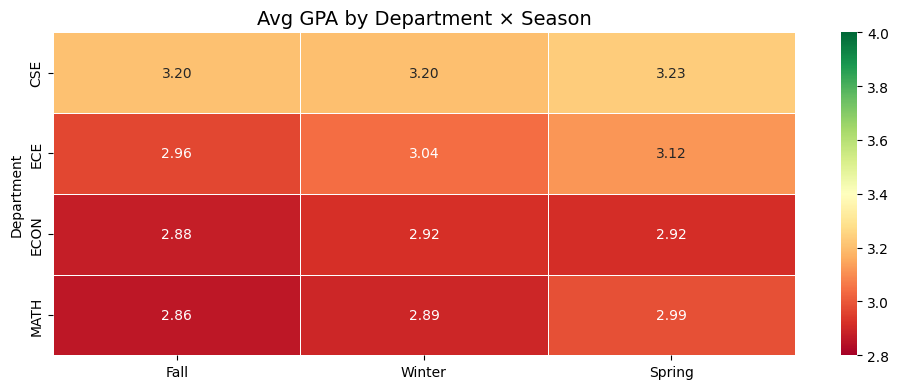

In [5]:
FOCUS = sh.focus_departments(df_season)
pivot = sh.build_season_department_heatmap(df_season, FOCUS, season_order)
sh.plot_season_department_heatmap(pivot, 'figures/quarter_dept_heatmap.png')
pivot.round(3)


### 3.3 Recommendation Rate by Season

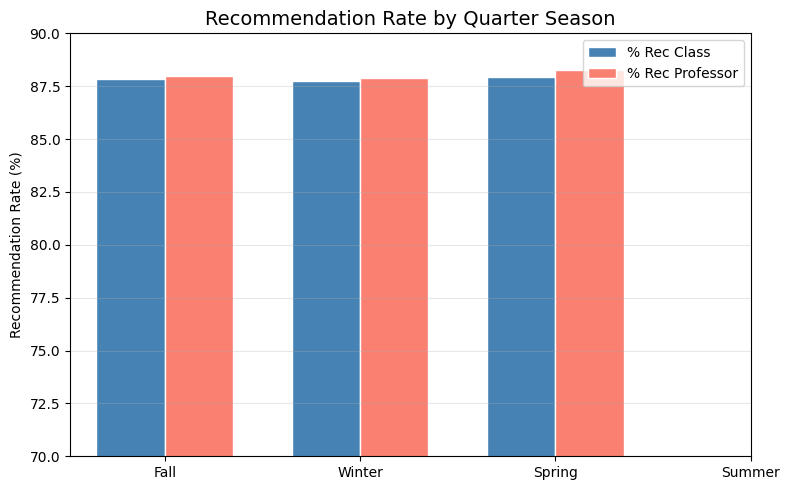

In [6]:
season_rec = sh.summarize_season_recommendations(df_season, season_order)
sh.plot_season_recommendations(season_rec, 'figures/quarter_rec_rate.png')
season_rec.round(2)


### 3.4 Study Hours by Season

C:\Users\admin\AppData\Local\Temp\ipykernel_1700\2689100080.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


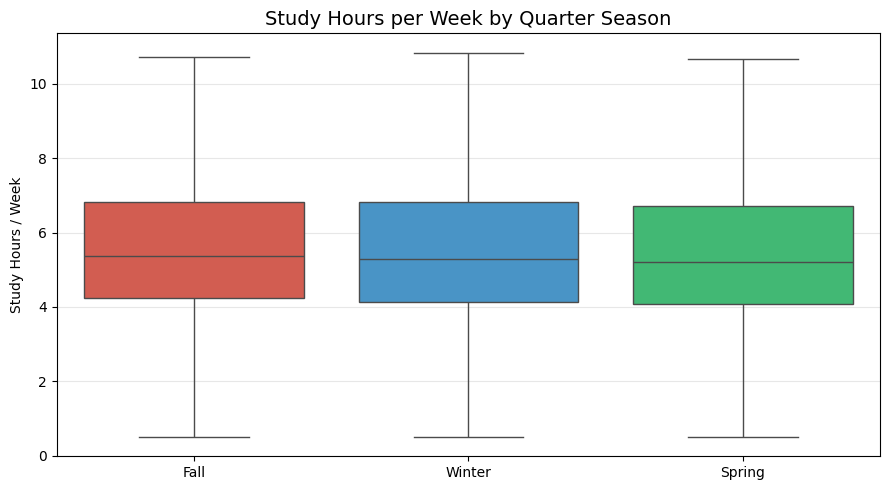

             mean  median
Season_Name              
Fall         5.71    5.38
Spring       5.65    5.22
Winter       5.68    5.30


In [7]:
df_hours = sh.filter_season_hours(df_season)
sh.plot_season_study_hours(df_hours, season_order, 'figures/quarter_study_hours.png')
print(df_hours.groupby('Season_Name')['Study Hours per Week'].describe().round(2))


## 4. Summary — Sub-Hypothesis Findings

In [8]:
sh.print_sub_hypothesis_summary(df_size, season_gpa, df_hours)


=== Class Size vs Satisfaction ===
  Enrollment vs Rec Class:    r = -0.159
  Enrollment vs Rec Prof:     r = -0.135
  Enrollment vs GPA:          r = -0.268

=== GPA by Season ===
              mean    count
Season_Name                
Fall         3.240  13267.0
Winter       3.269  14121.0
Spring       3.314  13791.0
Summer         NaN      NaN

Best season: Spring (3.314)
Worst season: Fall (3.240)
